In [1]:
# 한글 깨짐 방지 — 운영체제별 자동 폰트 설정(이후 모든 예제 공통)
import platform
import matplotlib.pyplot as plt
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")     # 맑은 고딕
elif platform.system() == "Darwin":            # macOS
    plt.rc("font", family="AppleGothic")
else:                                          # Linux
    plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False     # 음수 부호 깨짐 방지

In [2]:
import seaborn as sns
tips = sns.load_dataset("tips")     # 시바로 제공되는 예제 데이터
print(tips.head())                  # 상위 5개
print(tips.describe())              # 개수·평균·표준편차·최소·최대

# 그룹별 통계: 요일별 팁 평균
print(tips.groupby("day")["tip"].mean())
print(tips.groupby("day")["tip"].agg(["mean", "std", "min", "max"]))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000
day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64
          mean       std   min    max
day                                  
Thur  2.771452  1.240223  1.25   6.70
Fri   2.734737  1.019577  1.00   4.73
Sat   2.993103  1.631014  1.00  10.00
Sun   3.25

c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54017 (\N{HANGUL SYLLABLE TIB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  fig.c

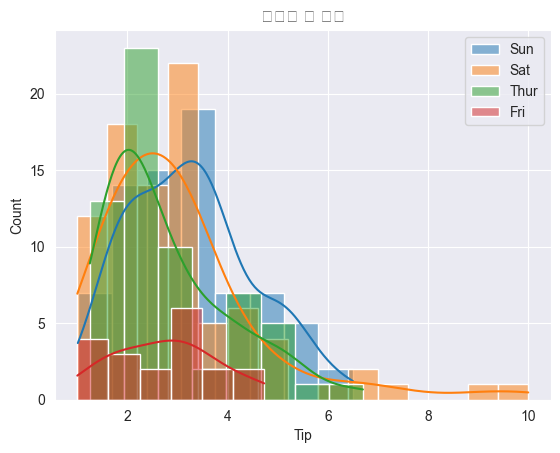

In [3]:
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
for day in tips["day"].unique():
    subset = tips[tips["day"] == day]      # 요일별로 분리
    sns.histplot(subset["tip"], kde=True, label=day)  # kde: 부드러운 분포갡선
plt.title("요일별 팁 분포"); plt.xlabel("Tip"); plt.legend(); plt.show()

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49707 (\N{HANGUL SYLLABLE SUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fi

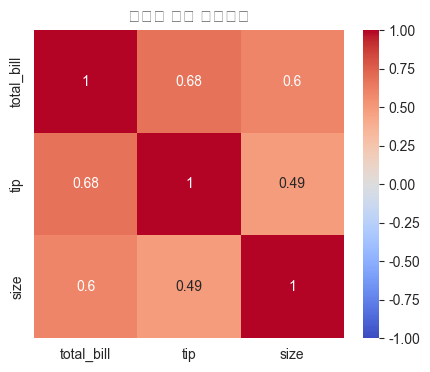

In [4]:
num_cols = ["total_bill", "tip", "size"]   # 숫자형 열만
corr_matrix = tips[num_cols].corr()         # 상관계수 행렬
print(corr_matrix)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
# annot=True: 칸안에 숫자 표시 / coolwarm: 음=파랑, 양=빨강
plt.title("숫자형 변수 상관관계"); plt.show()

In [8]:
import statsmodels.api as sm
X = tips[["total_bill", "size"]]   # 독립변수
y = tips["tip"]                     # 종속변수
X = sm.add_constant(X)             # 절편(상수항) 추가
model = sm.OLS(y, X).fit()         # 모델 적합
print(model.summary())             # R-squared, coef, p-값 등 전체 요약

# 해석 포인트: P>|t| 값이 0.05 미만인 변수가 tip에 유의미한 영향

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           9.67e-34
Time:                        11:23:11   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6689      0.194      3.455      0.0

In [9]:
import seaborn as sns
tips = sns.load_dataset("tips")
print(tips.groupby("sex")["total_bill"].mean())

sex
Male      20.744076
Female    18.056897
Name: total_bill, dtype: float64


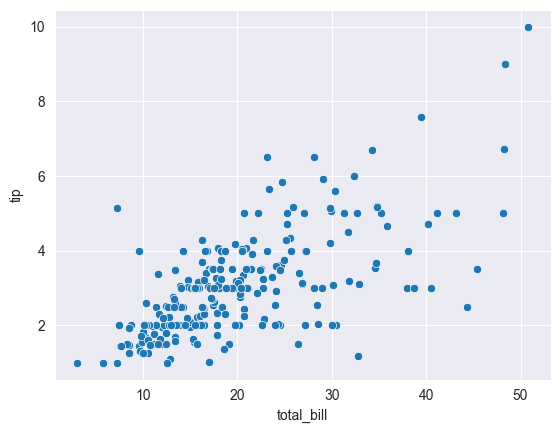

In [10]:
import matplotlib.pyplot as plt
sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.show()

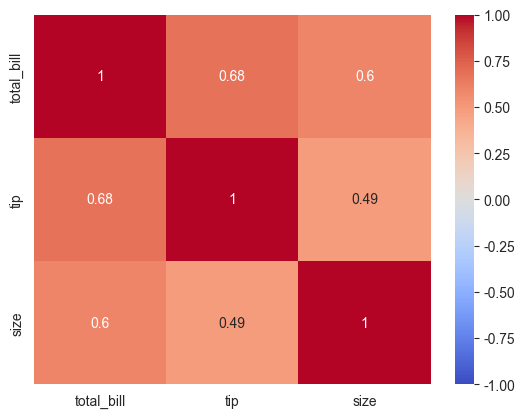

In [11]:
corr = tips[["total_bill", "tip", "size"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

In [12]:
import statsmodels.api as sm
X = sm.add_constant(tips[["total_bill"]])
model = sm.OLS(tips["tip"], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           6.69e-34
Time:                        11:39:42   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0